### 1. Data Loading & Schema Handling

In [ ]:
# 1. Load data and check schemas
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import pandas as pd

spark = SparkSession.builder.appName("COVID_Analytics").getOrCreate()

dfs = {
    "full_grouped": spark.read.csv("data/full_grouped.csv", header=True, inferSchema=True),
    "clean_complete": spark.read.csv("data/covid_19_clean_complete.csv", header=True, inferSchema=True),
    "country_latest": spark.read.csv("data/country_wise_latest.csv", header=True, inferSchema=True),
    "day_wise": spark.read.csv("data/day_wise.csv", header=True, inferSchema=True),
    "usa_county": spark.read.csv("data/usa_county_wise.csv", header=True, inferSchema=True),
    "worldometer": spark.read.csv("data/worldometer_data.csv", header=True, inferSchema=True)
}

for name, df in dfs.items():
    df.printSchema()
    print(df.count())

root
 |-- Date: date (nullable = true)
 |-- Country/Region: string (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- New cases: integer (nullable = true)
 |-- New deaths: integer (nullable = true)
 |-- New recovered: integer (nullable = true)
 |-- WHO Region: string (nullable = true)

35156
root
 |-- Province/State: string (nullable = true)
 |-- Country/Region: string (nullable = true)
 |-- Lat: double (nullable = true)
 |-- Long: double (nullable = true)
 |-- Date: date (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- WHO Region: string (nullable = true)

49068
root
 |-- Country/Region: string (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nul

### 2. Data Cleaning Tasks

In [2]:
# 2. Clean data and drop duplicates
dfs["clean_complete"].filter(F.col("Province/State").isNull()).groupBy("Country/Region").count().withColumnRenamed("count", "Null_Count").show()

dfs["clean_complete"] = dfs["clean_complete"].fillna({"Province/State": "Unknown"})

for k in ["full_grouped", "country_latest", "worldometer"]:
    dfs[k] = dfs[k].withColumn("Country/Region", F.regexp_replace(F.regexp_replace(F.col("Country/Region"), "^US$", "USA"), "^Korea$", "South Korea"))

dfs["full_grouped"] = dfs["full_grouped"].dropDuplicates(["Country/Region", "Date"])

+--------------+----------+
|Country/Region|Null_Count|
+--------------+----------+
|          Chad|       188|
|      Paraguay|       188|
|        Russia|       188|
|         Yemen|       188|
|       Senegal|       188|
|    Cabo Verde|       188|
|        Sweden|       188|
|        Guyana|       188|
|       Eritrea|       188|
|   Philippines|       188|
|         Burma|       188|
|      Djibouti|       188|
|      Malaysia|       188|
|     Singapore|       188|
|          Fiji|       188|
|        Turkey|       188|
|        Malawi|       188|
|Western Sahara|       188|
|          Iraq|       188|
|       Germany|       188|
+--------------+----------+
only showing top 20 rows


### 3. Aggregation Tasks

Top 10 Countries by Total Confirmed:
Country/Region  Confirmed
           USA    4290259
        Brazil    2442375
         India    1480073
        Russia     816680
  South Africa     452529
        Mexico     395489
          Peru     389717
         Chile     347923
United Kingdom     301708
          Iran     293606




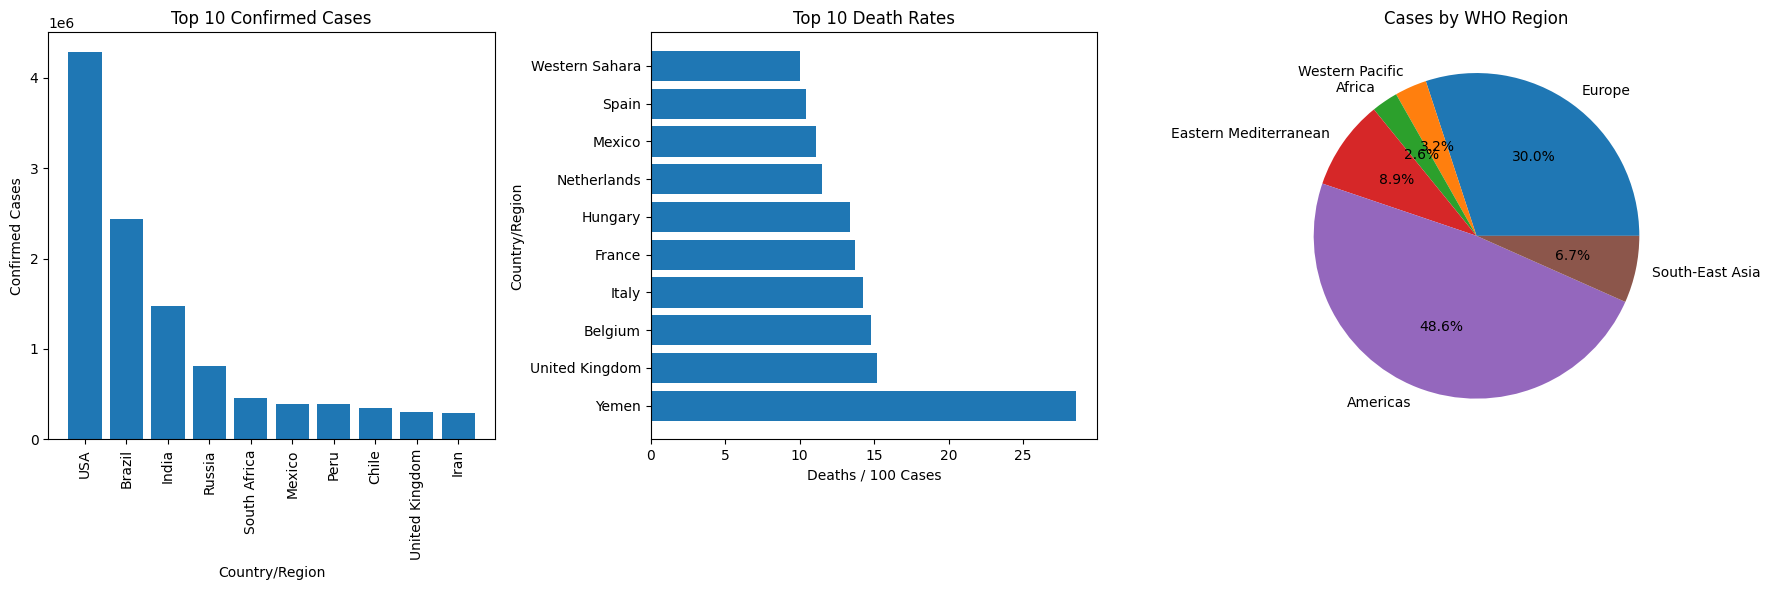

In [3]:
# 3. Aggregate datasets and visualize
top_cases = dfs["country_latest"].select("Country/Region", "Confirmed").orderBy(F.col("Confirmed").desc()).limit(10).toPandas()
top_deaths = dfs["country_latest"].select("Country/Region", "Deaths / 100 Cases").orderBy(F.col("Deaths / 100 Cases").desc()).limit(10).toPandas()
who_summary = dfs["full_grouped"].groupBy("WHO Region").agg(F.sum("Confirmed").alias("Total_Cases"), F.sum("Deaths").alias("Total_Deaths"), F.sum("Recovered").alias("Total_Recovered")).toPandas()

print("Top 10 Countries by Total Confirmed:")
print(top_cases.to_string(index=False))
print("\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].bar(top_cases["Country/Region"], top_cases["Confirmed"])
axes[0].set_title("Top 10 Confirmed Cases")
axes[0].set_ylabel("Confirmed Cases")
axes[0].set_xlabel("Country/Region")
axes[0].tick_params(axis='x', rotation=90)

axes[1].barh(top_deaths["Country/Region"], top_deaths["Deaths / 100 Cases"])
axes[1].set_title("Top 10 Death Rates")
axes[1].set_xlabel("Deaths / 100 Cases")
axes[1].set_ylabel("Country/Region")

axes[2].pie(who_summary["Total_Cases"], labels=who_summary["WHO Region"], autopct='%1.1f%%')
axes[2].set_title("Cases by WHO Region")

plt.tight_layout()
plt.show()

### 4. Time-Series Analysis

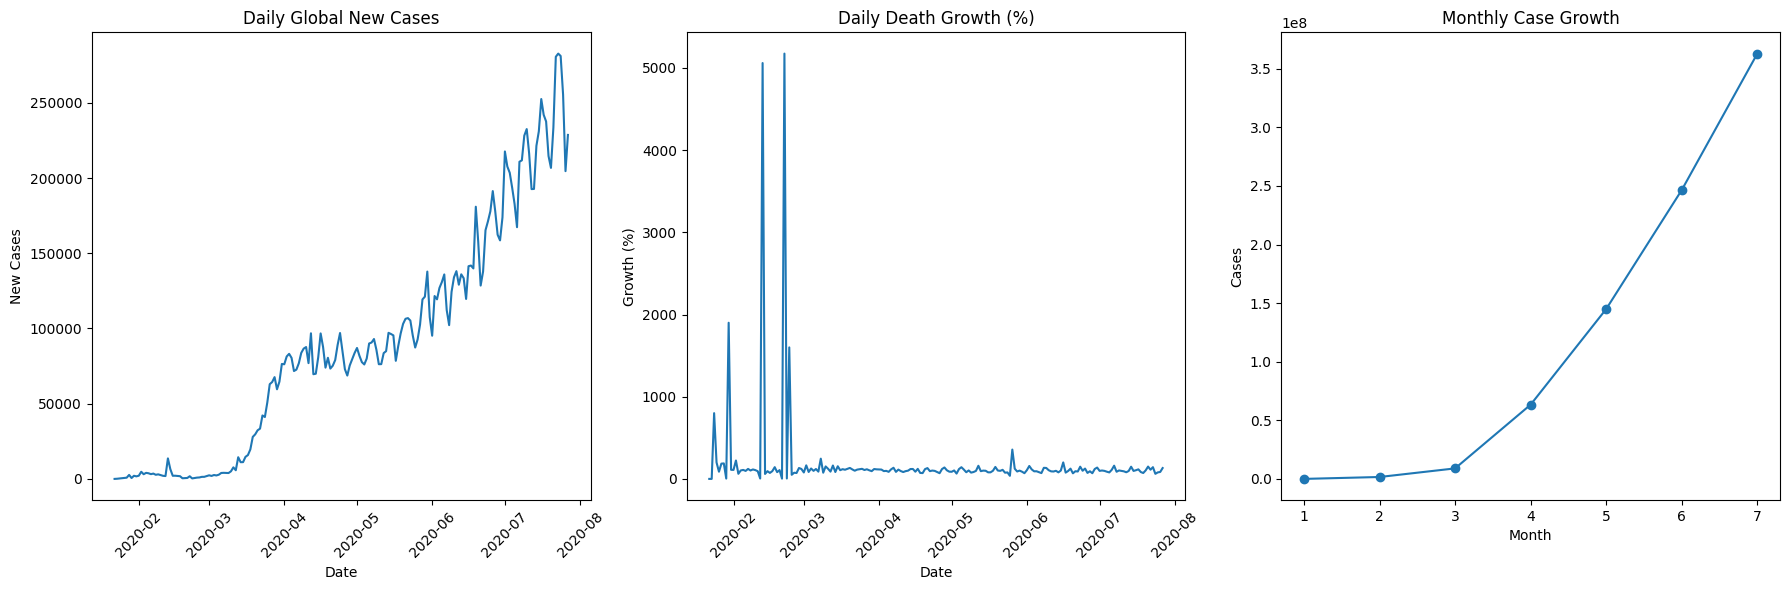

In [4]:
# 4. Analyze time series trends
daily = dfs["day_wise"].orderBy("Date").toPandas()
death_growth = dfs["day_wise"].withColumn("Prev_Deaths", F.lag("New deaths").over(Window.orderBy("Date"))).withColumn("Death_Growth", F.when((F.col("Prev_Deaths").isNull()) | (F.col("Prev_Deaths") == 0), 0).otherwise((F.col("New deaths") / F.col("Prev_Deaths")) * 100)).toPandas()
monthly = dfs["full_grouped"].withColumn("Month", F.month("Date")).groupBy("Month").agg(F.sum("Confirmed").alias("Monthly_Cases")).orderBy("Month").toPandas()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].plot(pd.to_datetime(daily["Date"]), daily["New cases"])
axes[0].set_title("Daily Global New Cases")
axes[0].set_ylabel("New Cases")
axes[0].set_xlabel("Date")
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(pd.to_datetime(death_growth["Date"]), death_growth["Death_Growth"])
axes[1].set_title("Daily Death Growth (%)")
axes[1].set_ylabel("Growth (%)")
axes[1].set_xlabel("Date")
axes[1].tick_params(axis='x', rotation=45)

axes[2].plot(monthly["Month"], monthly["Monthly_Cases"], marker='o')
axes[2].set_title("Monthly Case Growth")
axes[2].set_ylabel("Cases")
axes[2].set_xlabel("Month")
axes[2].set_xticks(monthly["Month"])

plt.tight_layout()
plt.show()

### 5. Window Function Tasks

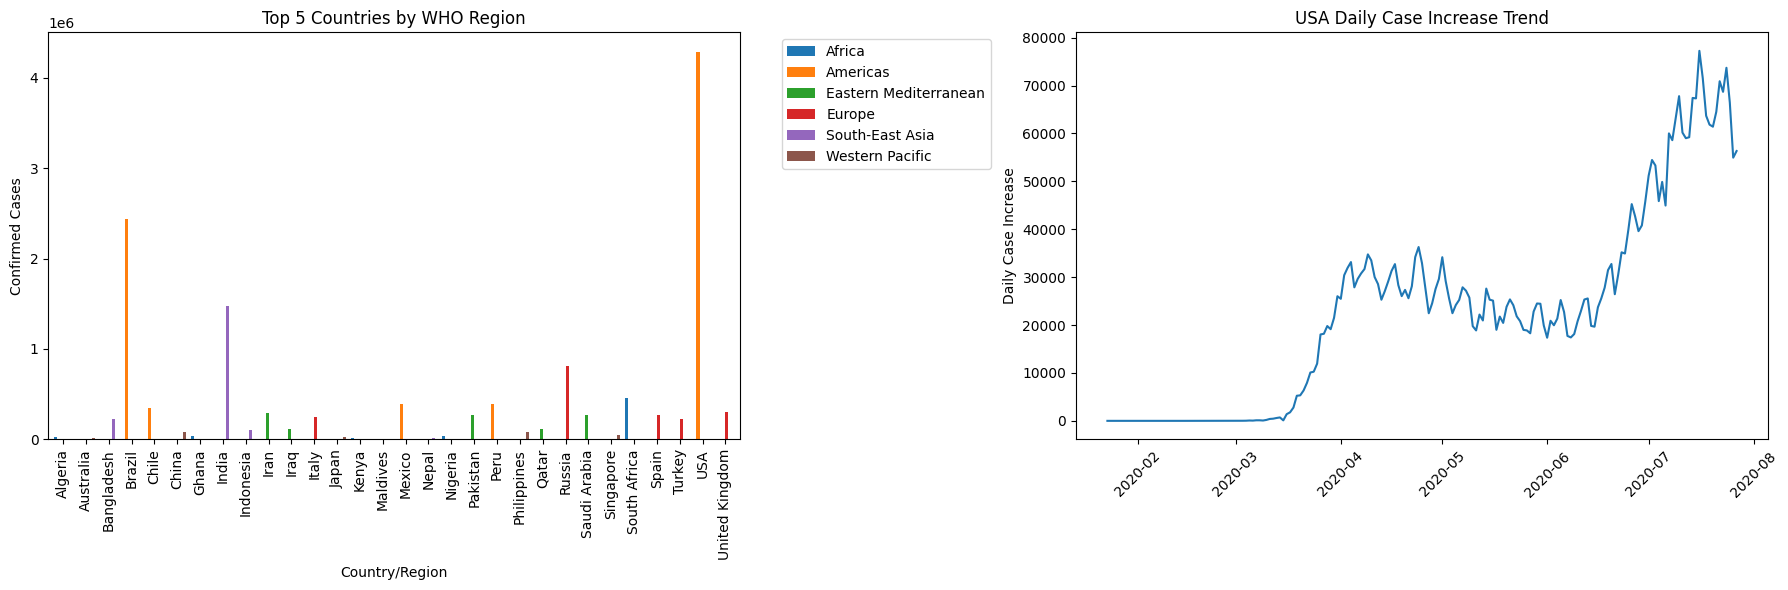

In [5]:
# 5. Region rankings and case growth
top_5_region = dfs["country_latest"].withColumn("Rank", F.dense_rank().over(Window.partitionBy("WHO Region").orderBy(F.col("Confirmed").desc()))).filter(F.col("Rank") <= 5).toPandas()
usa_trend = dfs["full_grouped"].filter(F.col("Country/Region") == "USA").withColumn("Daily_Increase", F.col("Confirmed") - F.lag("Confirmed").over(Window.partitionBy("Country/Region").orderBy("Date"))).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
top_5_region.pivot(index="Country/Region", columns="WHO Region", values="Confirmed").plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title("Top 5 Countries by WHO Region")
axes[0].set_ylabel("Confirmed Cases")
axes[0].tick_params(axis='x', rotation=90)
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

axes[1].plot(pd.to_datetime(usa_trend["Date"]), usa_trend["Daily_Increase"])
axes[1].set_title("USA Daily Case Increase Trend")
axes[1].set_ylabel("Daily Case Increase")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 6. Join Operations

Countries With Large Mismatches (>10,000):
+--------------+--------------+----------+-------------+
|Country/Region|Confirmed_Diff|Death_Diff|Recovery_Diff|
+--------------+--------------+----------+-------------+
|           USA|        741920|     14793|      1250864|
|        Brazil|        475187|     11026|       201019|
|         India|        545336|      8230|       426218|
|        Russia|         55214|      1272|        74108|
|  South Africa|         85655|      2537|       112391|
|        Mexico|         67201|      6495|         5038|
|          Peru|         65692|      2006|        37790|
|         Chile|         18748|       702|        20214|
|      Colombia|        100609|      3162|        61194|
|         Spain|         82109|        68|         NULL|
|          Iran|         26511|      2064|        22319|
|  Saudi Arabia|         15292|       295|        24153|
|    Bangladesh|         23426|       341|        18141|
|        Turkey|         10246|       168|   

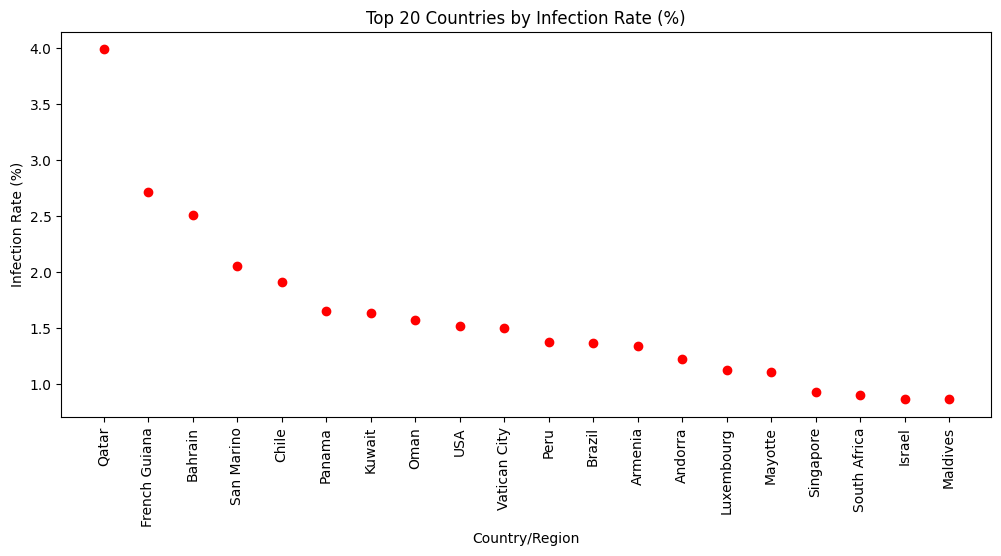

In [6]:
# 6. Compare datasets and infection rates
mismatches = dfs["country_latest"].alias("c").join(dfs["worldometer"].alias("w"), "Country/Region").select("Country/Region", F.abs(F.col("c.Confirmed") - F.col("w.TotalCases")).alias("Confirmed_Diff"), F.abs(F.col("c.Deaths") - F.col("w.TotalDeaths")).alias("Death_Diff"), F.abs(F.col("c.Recovered") - F.col("w.TotalRecovered")).alias("Recovery_Diff")).filter(F.col("Confirmed_Diff") > 10000)
infection_rates = dfs["worldometer"].filter(F.col("Population") > 0).withColumn("Infection_Rate", (F.col("TotalCases") / F.col("Population")) * 100).orderBy(F.col("Infection_Rate").desc()).limit(20).toPandas()

print("Countries With Large Mismatches (>10,000):")
mismatches.show()

plt.figure(figsize=(12, 5))
plt.scatter(infection_rates["Country/Region"], infection_rates["Infection_Rate"], color='red')
plt.xticks(rotation=90)
plt.title("Top 20 Countries by Infection Rate (%)")
plt.xlabel("Country/Region")
plt.ylabel("Infection Rate (%)")
plt.show()

### 7. Geographic Analysis

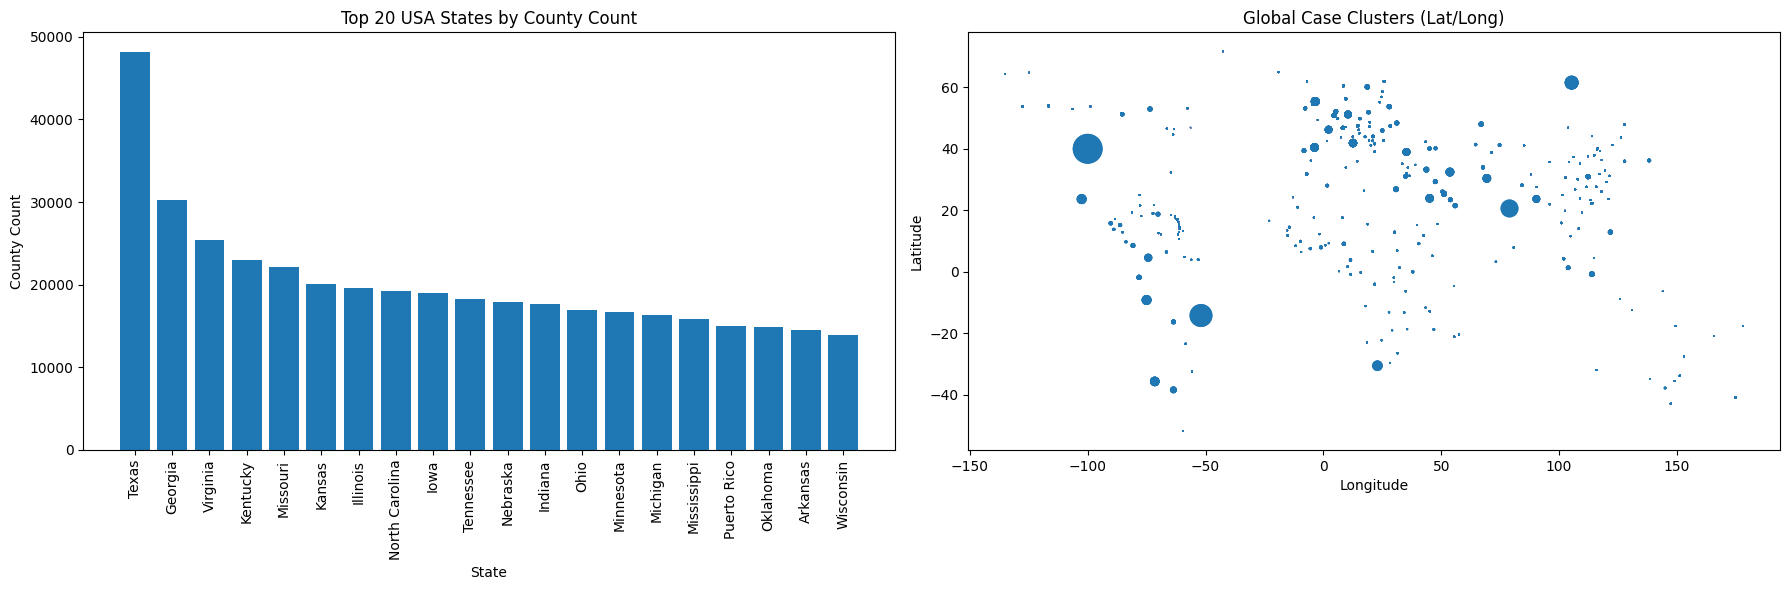

In [7]:
# 7. Geo distribution
usa_states = dfs["usa_county"].groupBy("Province_State").count().orderBy(F.col("count").desc()).limit(20).toPandas()
geo_data = dfs["clean_complete"].select("Lat", "Long", "Confirmed").filter(F.col("Lat").isNotNull() & F.col("Long").isNotNull() & (F.col("Confirmed") > 0)).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].bar(usa_states["Province_State"], usa_states["count"])
axes[0].set_title("Top 20 USA States by County Count")
axes[0].set_xlabel("State")
axes[0].set_ylabel("County Count")
axes[0].tick_params(axis='x', rotation=90)

axes[1].scatter(geo_data["Long"], geo_data["Lat"], s=geo_data["Confirmed"]/10000, alpha=0.5)
axes[1].set_title("Global Case Clusters (Lat/Long)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()

### 8. Advanced Analytical Tasks

High-Risk Countries (Active Cases > Recovered):
+--------------------+------+---------+
|      Country/Region|Active|Recovered|
+--------------------+------+---------+
|              Angola|   667|      242|
|           Argentina| 91782|    72575|
|             Bahamas|   280|       91|
|             Belgium| 39154|    17452|
|             Bolivia| 47056|    21478|
|Bosnia and Herzeg...|  5274|     4930|
|            Botswana|   674|       63|
|              Canada|107514|        0|
|Central African R...|  2994|     1546|
| Congo (Brazzaville)|  2317|      829|
+--------------------+------+---------+
only showing top 10 rows


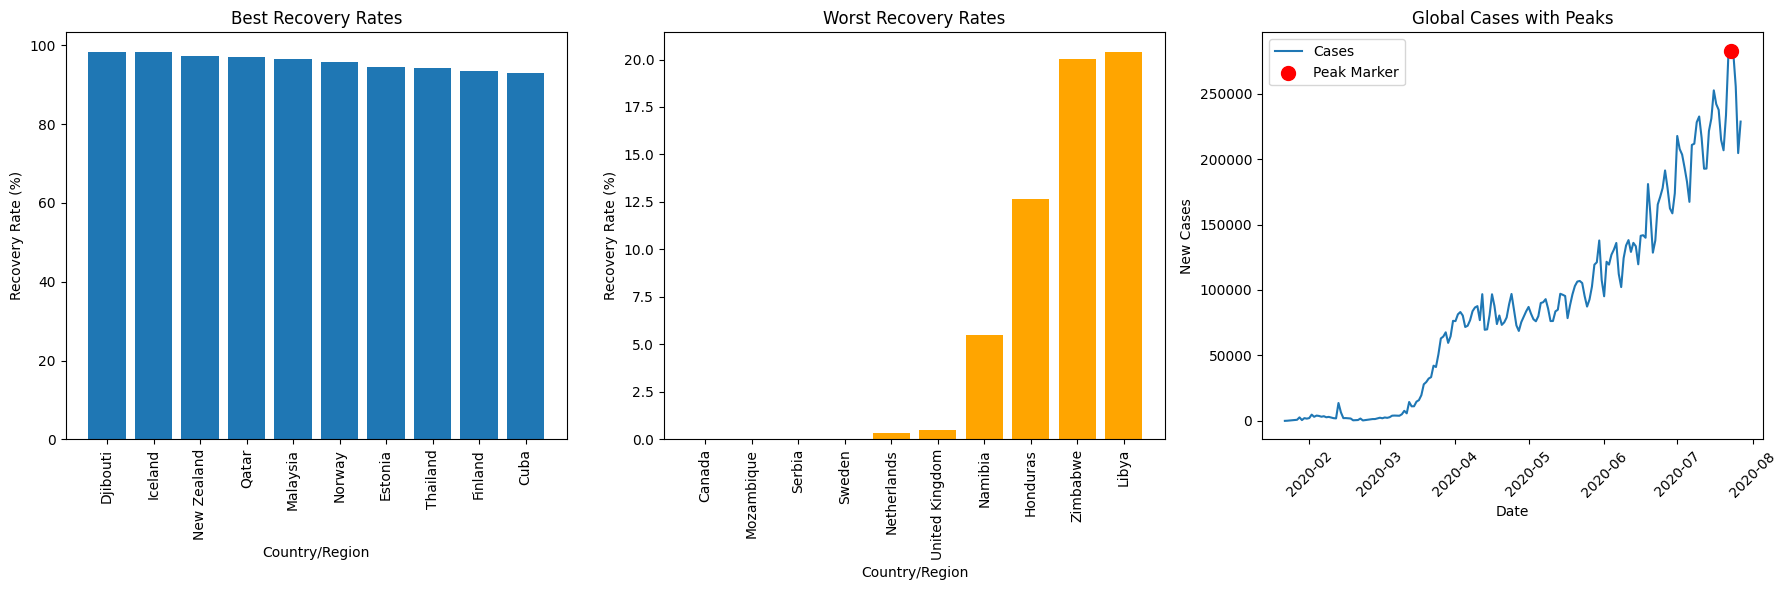

In [ ]:
# 8. Recovery and peaks analysis
recovery = dfs["country_latest"].filter(F.col("Confirmed") > 1000).withColumn("Rec_Rate", (F.col("Recovered") / F.col("Confirmed")) * 100)
best_rec = recovery.orderBy(F.col("Rec_Rate").desc()).limit(10).toPandas()
worst_rec = recovery.orderBy(F.col("Rec_Rate").asc()).limit(10).toPandas()
high_risk = dfs["country_latest"].filter(F.col("Active") > F.col("Recovered")).select("Country/Region", "Active", "Recovered")

peaks = dfs["day_wise"].agg(F.max("New cases").alias("Max_Cases"), F.max("New deaths").alias("Max_Deaths")).collect()[0]
peak_dates = dfs["day_wise"].filter((F.col("New cases") == peaks["Max_Cases"]) | (F.col("New deaths") == peaks["Max_Deaths"])).toPandas()

print("High-Risk Countries (Active Cases > Recovered):")
high_risk.show(10)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].bar(best_rec["Country/Region"], best_rec["Rec_Rate"])
axes[0].tick_params(axis='x', rotation=90)
axes[0].set_title("Best Recovery Rates")
axes[0].set_xlabel("Country/Region")
axes[0].set_ylabel("Recovery Rate (%)")

axes[1].bar(worst_rec["Country/Region"], worst_rec["Rec_Rate"], color='orange')
axes[1].tick_params(axis='x', rotation=90)
axes[1].set_title("Worst Recovery Rates")
axes[1].set_xlabel("Country/Region")
axes[1].set_ylabel("Recovery Rate (%)")

axes[2].plot(pd.to_datetime(daily["Date"]), daily["New cases"], label="Cases")
axes[2].scatter(pd.to_datetime(peak_dates["Date"]), peak_dates["New cases"], color='red', s=100, label="Peak Marker", zorder=5)
axes[2].set_title("Global Cases with Peaks")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("New Cases")
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

### 9. Feature Engineering

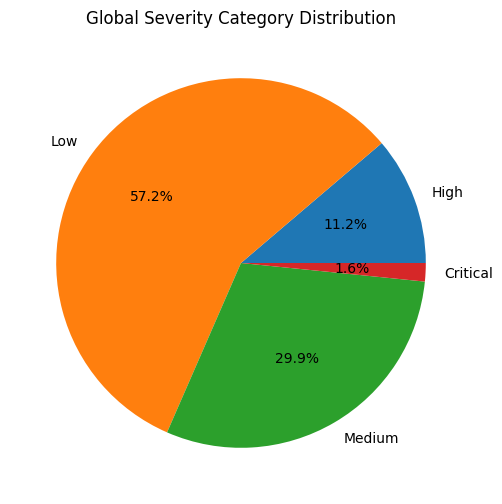

In [9]:
# 9. Severity categorization
severity = dfs["country_latest"].withColumn("Severity_Category", F.when(F.col("Confirmed") < 10000, "Low").when((F.col("Confirmed") >= 10000) & (F.col("Confirmed") <= 100000), "Medium").when((F.col("Confirmed") > 100000) & (F.col("Confirmed") <= 1000000), "High").otherwise("Critical"))

sev_counts = severity.groupBy("Severity_Category").count().toPandas()
plt.figure(figsize=(6, 6))
plt.pie(sev_counts["count"], labels=sev_counts["Severity_Category"], autopct='%1.1f%%')
plt.title("Global Severity Category Distribution")
plt.show()

### 10. Final Mini Pipeline Project

In [10]:
# 10. Export data and print insights
import os

os.makedirs("pipeline_output", exist_ok=True)

try:
    severity.toPandas().to_parquet("pipeline_output/severity_categories.parquet", index=False)
    who_summary.to_csv("pipeline_output/region_summary.csv", index=False)
    print("Output files successfully written to 'pipeline_output/' directory.\n")
except Exception as e:
    print(f"Could not write output files: {e}\n")

print("Final Report Insights:")
print(f"Highest Death Rate: {top_deaths.iloc[0]['Country/Region']}")
print(f"Fastest Recovering Region: {who_summary.sort_values('Total_Recovered', ascending=False).iloc[0]['WHO Region']}")
print(f"Global Cases Peaked On: {peak_dates[peak_dates['New cases'] == peaks['Max_Cases']]['Date'].values[0]}")
print(f"Global Deaths Peaked On: {peak_dates[peak_dates['New deaths'] == peaks['Max_Deaths']]['Date'].values[0]}")
print(f"Best Recovery Handling Country: {best_rec.iloc[0]['Country/Region']}")

Output files successfully written to 'pipeline_output/' directory.

Final Report Insights:
Highest Death Rate: Yemen
Fastest Recovering Region: Americas
Global Cases Peaked On: 2020-07-23
Global Deaths Peaked On: 2020-07-23
Best Recovery Handling Country: Djibouti
